<a href="https://colab.research.google.com/github/Amarmurun0212/Diver/blob/main/AI%26MLles7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Өгөгдлийн эхний 5 мөр ===
         Date  Rainfall_mm  Umbrellas_Sold
0  2025-01-01         76.7             244
1  2025-01-02         26.8              92
2  2025-01-03         88.4             245
3  2025-01-04         10.4              10
4  2025-01-05         50.6             169

=== Корреляцын коэффициент ===
Correlation: 0.982

=== Model Evaluation ===
MSE: 261.93
R2 Score: 0.9759

=== Шугаман Регрессийн Тэгшитгэл ===
Umbrellas_Sold = 2.84 * Rainfall_mm + 11.67


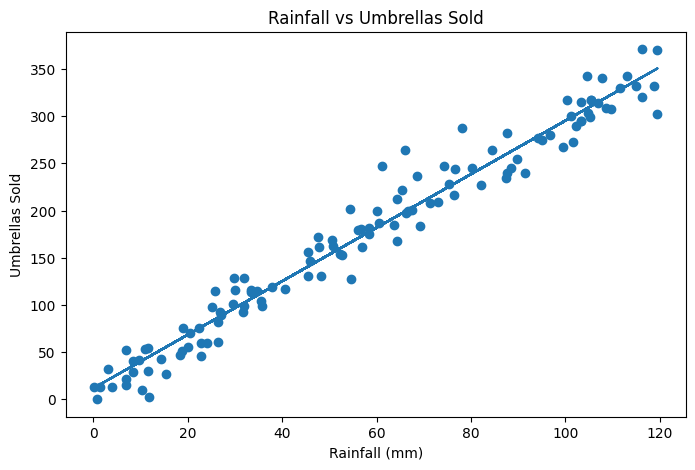


=== Шинэ Prediction ===
50 мм бороонд ойролцоогоор 153 шүхэр зарагдана.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================
# Rainfall vs Umbrellas Sold
# Корреляц болон Шугаман Регресс
# ============================================
# pandas -> өгөгдөл унших, боловсруулах сан
import pandas as pd
# numpy -> тооцооллын сан
import numpy as np
# matplotlib -> график зурах сан
import matplotlib.pyplot as plt
# sklearn -> Machine Learning сан
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# ============================================
# 1. Excel файл унших
# ============================================
# Excel файлын нэр
file_path = "rainfall_umbrella_regression_data.xlsx"
# DataFrame болгон уншина
df = pd.read_excel(file_path)
# Эхний 5 мөрийг харах
print("=== Өгөгдлийн эхний 5 мөр ===")
print(df.head())
# ============================================
# 2. Корреляцын коэффициент олох
# ============================================
# Rainfall болон Umbrellas_Sold багануудын корреляц
correlation = df["Rainfall_mm"].corr(df["Umbrellas_Sold"])
print("\n=== Корреляцын коэффициент ===")
print("Correlation:", round(correlation, 4))
# Тайлбар
# +1  -> маш хүчтэй эерэг хамаарал
#  0  -> хамааралгүй
# -1  -> маш хүчтэй сөрөг хамаарал
# ============================================
# 3. Feature болон Target тодорхойлох
# ============================================
# X -> Оролтын өгөгдөл (Feature)
# Rainfall_mm баганыг ашиглана
X = df[["Rainfall_mm"]]
# y -> Таамаглах утга (Target)
y = df["Umbrellas_Sold"]
# ============================================
# 4. Train/Test өгөгдөл хуваах
# ============================================
# train_test_split:
# Өгөгдлийг сургалтын болон тестийн хэсэгт хуваана
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # 20% нь тест
    random_state=42  # Давтагдах үр дүн
)
# ============================================
# 5. Шугаман Регрессийн Model үүсгэх
# ============================================
# LinearRegression model үүсгэнэ
model = LinearRegression()
# Model-оо сургах (training)
model.fit(X_train, y_train)
# ============================================
# 6. Prediction хийх
# ============================================
# Тест өгөгдөл дээр prediction хийх
y_pred = model.predict(X_test)
# ============================================
# 7. Model үнэлэх
# ============================================
# MSE -> Алдааны дундаж квадрат
mse = mean_squared_error(y_test, y_pred)
# R² Score -> Model хэр сайн тайлбарлаж байгааг хэмжинэ
r2 = r2_score(y_test, y_pred)
print("\n=== Model Evaluation ===")
print("MSE:", round(mse, 2))
print("R2 Score:", round(r2, 4))
# ============================================
# 8. Регрессийн тэгшитгэл хэвлэх
# ============================================
# coef_ -> налуу (slope)
slope = model.coef_[0]
# intercept_ -> огтлолцол (intercept)
intercept = model.intercept_
print("\n=== Шугаман Регрессийн Тэгшитгэл ===")
print(f"Umbrellas_Sold = {slope:.2f} * Rainfall_mm + {intercept:.2f}")
# ============================================
# 9. График дүрслэл
# ============================================
plt.figure(figsize=(8, 5))
# Бодит өгөгдөл
plt.scatter(X, y)
# Регрессийн шугам
plt.plot(X, model.predict(X))
# Гарчиг болон тайлбар
plt.title("Rainfall vs Umbrellas Sold")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Umbrellas Sold")
# График харуулах
plt.show()
# ============================================
# 10. Шинэ утга prediction хийх
# ============================================
# Жишээ:
# 50 мм бороо орвол хэдэн шүхэр зарагдах вэ?
new_rainfall = np.array([[50]])
predicted_sales = model.predict(new_rainfall)
print("\n=== Шинэ Prediction ===")
print(f"50 мм бороонд ойролцоогоор {predicted_sales[0]:.0f} шүхэр зарагдана.")